In [21]:
from c_elegans_colors import c_elegans_colors
from c_elegans_edges import c_elegans_edges
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
N, I, groups = c_elegans_colors()
G = nx.Graph(c_elegans_edges(), attr=dict(zip(I, groups)))
G.remove_edges_from(nx.selfloop_edges(G)) # get rid of self-loops


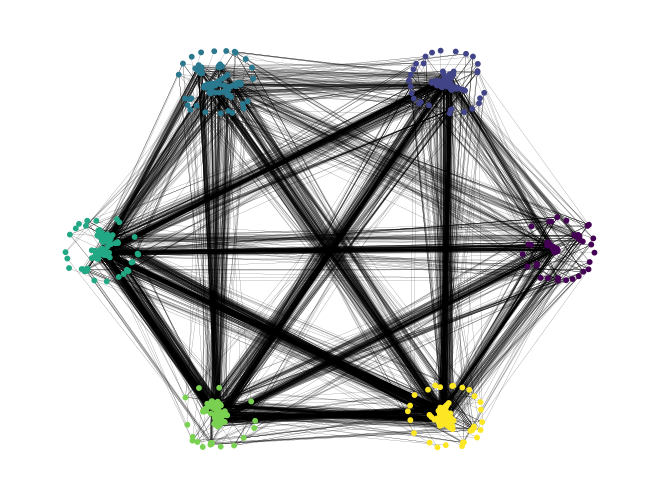

In [31]:
pos = {}
unique_groups = list(set(groups))

# 1. Arrange the centers of each group in a circle
#    (scale determines how far apart the clusters are from each other)
group_centers = nx.circular_layout(unique_groups, scale=3.0)

# 2. Group nodes by their group_id
grouped_nodes = {g: [] for g in unique_groups}
for node, g in zip(G.nodes(), groups):
    grouped_nodes[g].append(node)
    
# 3. Run a spring layout per cluster
for g, nodes in grouped_nodes.items():
    # Create a subgraph of just this cluster to calculate spring layout
    subgraph = G.subgraph(nodes)
    
    # Calculate positions centered around the group's assigned center
    # (scale determines how spread out the nodes are within their own cluster)
    sub_pos = nx.spring_layout(subgraph, center=group_centers[g], scale=0.5)
    
    # Update the master position dictionary
    pos.update(sub_pos)

# 4. Draw the graph
nx.draw(G, pos=pos, node_size=10, node_color=groups, width=0.1)

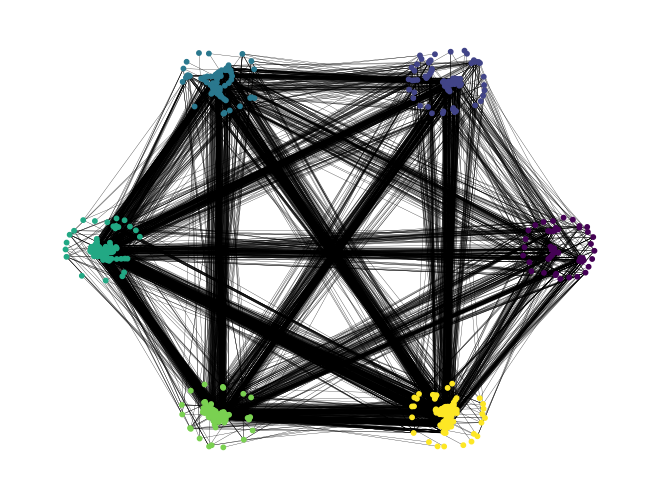

In [30]:
import random

# Create a randomly shuffled copy of the group assignments
shuffled_groups = groups.copy()
random.shuffle(shuffled_groups)

pos = {}
unique_groups = list(set(shuffled_groups))

# 1. Arrange the centers of each group in a circle
group_centers = nx.circular_layout(unique_groups, scale=3.0)

# 2. Group nodes by their SHUFFLED group_id
grouped_nodes = {g: [] for g in unique_groups}
for node, g in zip(G.nodes(), shuffled_groups):
    grouped_nodes[g].append(node)
    
# 3. Run a spring layout per cluster
for g, nodes in grouped_nodes.items():
    subgraph = G.subgraph(nodes)
    sub_pos = nx.spring_layout(subgraph, center=group_centers[g], scale=0.5)
    pos.update(sub_pos)

# 4. Draw the graph using the shuffled groups
nx.draw(
    G, 
    pos=pos, 
    node_size=10, 
    node_color=shuffled_groups, 
    width=0.2
)

In [32]:
# 1. Assign the group label as a node attribute in the graph
for node, group_id in zip(G.nodes(), groups):
    G.nodes[node]['group'] = group_id

# 2. Compute the assortativity coefficient for that specific attribute
assortativity = nx.attribute_assortativity_coefficient(G, 'group')

print(f"Assortativity Coefficient: {assortativity:.4f}")

Assortativity Coefficient: 0.0066
